In [2]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Constants import *


import warnings
warnings.simplefilter("ignore")

/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# Load

In [2]:
KC_path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\iHSCA_20251110')
kc_data = sc.read_h5ad(os.path.join(KC_path, 'Keratinocyte_Karl_IntegratedAnnotation_2_20250531_Added_PCA.h5ad'), backed = 'r')

In [3]:
kc_data

AnnData object with n_obs × n_vars = 252122 × 75464 backed at '/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/iHSCA_20251110/Keratinocyte_Karl_IntegratedAnnotation_2_20250531_Added_PCA.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'Donor

<Axes: xlabel='integrated_UMAP_L21', ylabel='integrated_UMAP_L22'>

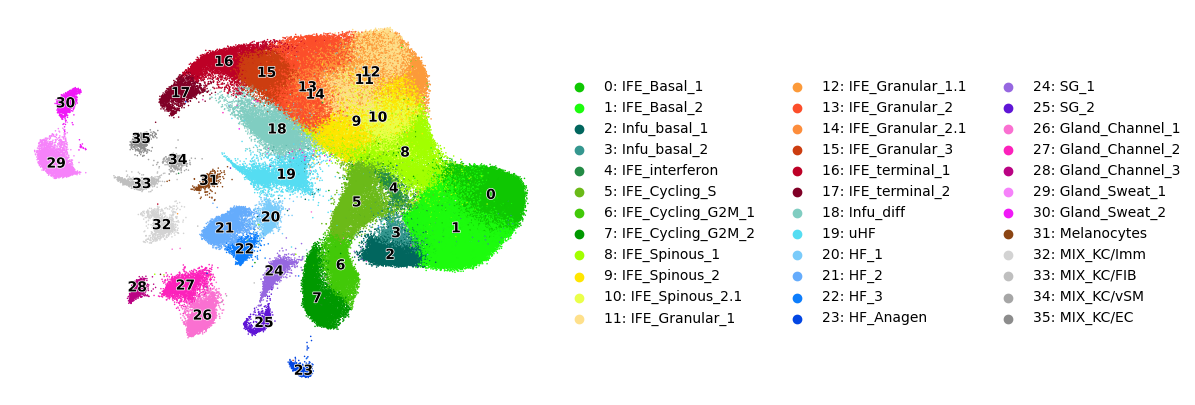

In [12]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(kc_data, color = 'Annotation_Level_2_FULL', basis = 'integrated_UMAP_L2', ax = ax, show = False, frameon = False, title = '', s = 5)
sc.pl.embedding(kc_data, color = 'Annotation_Level_2_renumber', basis = 'integrated_UMAP_L2', ax = ax, show = False, frameon = False, s = 0, legend_loc = 'on data', title = '', legend_fontoutline=True)

In [3]:
ober_data = sc.read_h5ad('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/OberReynolds_2023.h5ad')

In [6]:
ober_data

AnnData object with n_obs × n_vars = 28994 × 33538
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolog

In [26]:
ober_data.obs['LibraryPlatform'] = ober_data.obs['assay_ontology_term'].str.replace(' ', '_')

In [42]:
ober_data.obs['DonorID'] = ober_data.obs['donor_id_running']
ober_data.obs['StudyID'] = ober_data.obs['study_id']
ober_data.var = ober_data.var.reset_index().set_index('feature_name', drop = False)

In [43]:
ober_data_kc = ober_data[ober_data.obs['author_cell_type_1'] == 'Kc'].copy()
ober_data_kc

AnnData object with n_obs × n_vars = 10738 × 33538
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolog

# Integrate

In [46]:
shared_genes = ober_data_kc.var_names.intersection(kc_data.var_names)

In [ ]:
kc_data.X = kc_data.layers['raw_counts'].copy()

In [ ]:
adata = sc.concat([kc_data[:, shared_genes], ober_data_kc[:, shared_genes]], join = 'outer')
adata

In [61]:
adata

AnnData object with n_obs × n_vars = 262860 × 24285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Refer

## Process individual datasets

In [65]:
def process_data(adata):
    adata.layers['raw_counts'] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.layers['normalized'] = adata.X.copy()
    sc.pp.scale(adata, zero_center = True)
    adata.layers['scaled'] = adata.X.copy()
    return adata

adata = sc.concat([process_data(adata[adata.obs['StudyID']==study]) for study in adata.obs['StudyID'].unique()])
adata

AnnData object with n_obs × n_vars = 262860 × 24285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Refer

In [66]:
sc.pp.highly_variable_genes(adata, batch_key = 'StudyID', n_top_genes = 2000, layer = 'normalized')

## Integration as with HSCA KCs

In [68]:
key = 'harmonyDonorID_bbknnLibraryPlatform_hvg2000-StudyID'
sc.pp.pca(adata, use_highly_variable=True, layer='scaled')
sce.pp.harmony_integrate(adata, key = 'DonorID', adjusted_basis = 'harmonyDonorID')
bbknn.bbknn(adata, batch_key = 'LibraryPlatform', use_rep = 'harmonyDonorID', key_added = key)

2026-04-14 11:03:27,167 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 11:03:40,880 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-14 11:03:43,863 - harmonypy - INFO - Iteration 1 of 10
2026-04-14 11:06:28,504 - harmonypy - INFO - Iteration 2 of 10
2026-04-14 11:08:57,093 - harmonypy - INFO - Iteration 3 of 10
2026-04-14 11:11:15,228 - harmonypy - INFO - Iteration 4 of 10
2026-04-14 11:12:52,498 - harmonypy - INFO - Iteration 5 of 10
2026-04-14 11:14:24,923 - harmonypy - INFO - Iteration 6 of 10
2026-04-14 11:15:38,612 - harmonypy - INFO - Iteration 7 of 10
2026-04-14 11:17:07,249 - harmonypy - INFO - Iteration 8 of 10
2026-04-14 11:18:25,009 - harmonypy - INFO - Converged after 8 iterations


In [82]:
sc.tl.umap(adata, neighbors_key=key, key_added='umap_harmony')
sc.tl.leiden(adata, resolution = 1, key_added='leiden_harmony_100', neighbors_key=key)
sc.tl.leiden(adata, resolution = 2, key_added='leiden_harmony_200', neighbors_key=key)

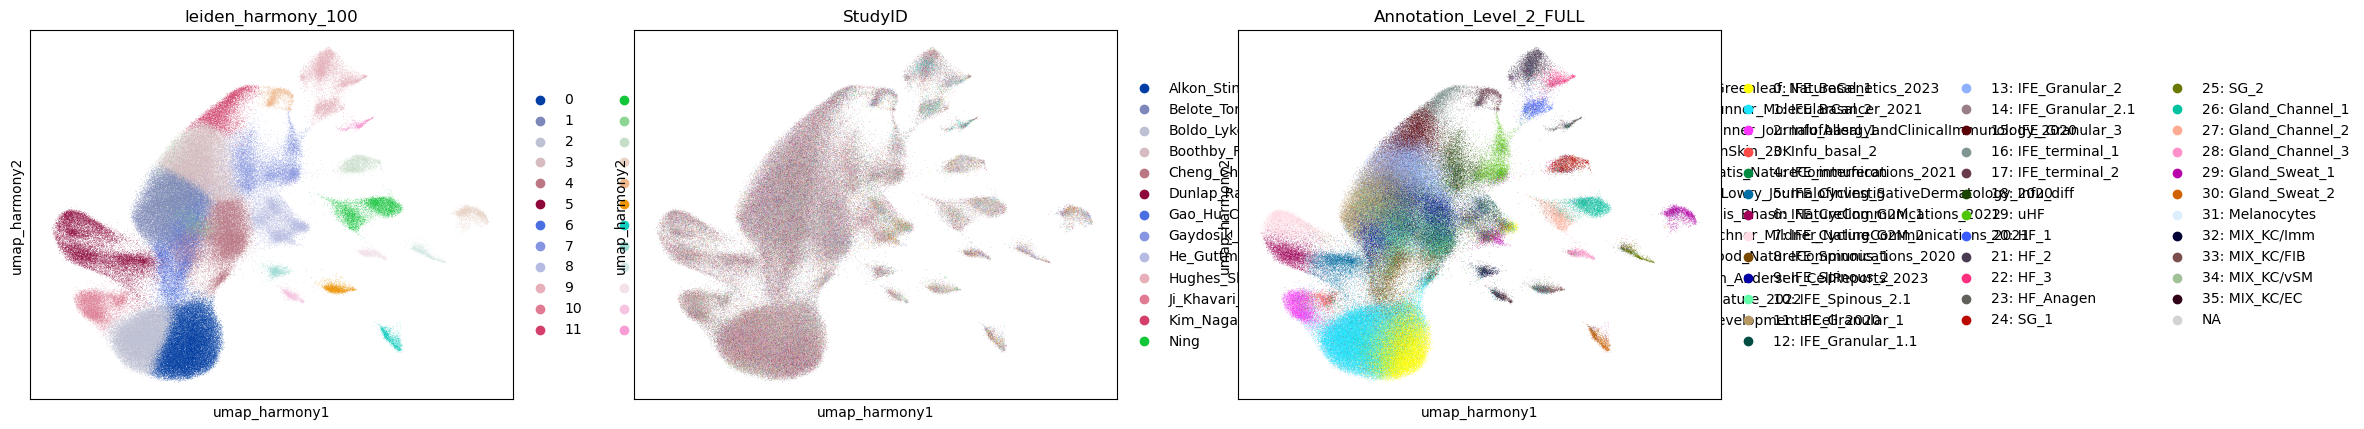

In [71]:
sc.pl.embedding(adata, basis = 'umap_harmony', color = ['leiden_harmony_100', 'StudyID', 'Annotation_Level_2_FULL'])

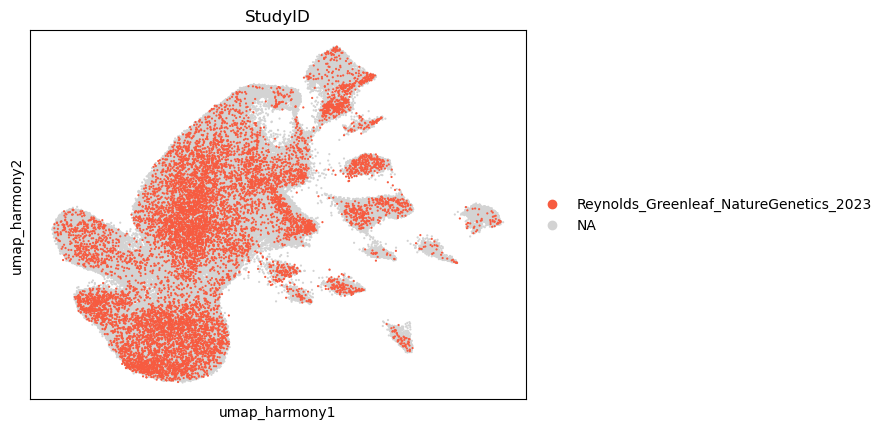

In [77]:
sc.pl.embedding(adata, basis = 'umap_harmony', color = 'StudyID', groups = ['Reynolds_Greenleaf_NatureGenetics_2023'], palette = 'Reds', s = 10)

# Plot confusion matrixes

In [78]:
adata.obs['integration'] = np.where(adata.obs['StudyID']=='Reynolds_Greenleaf_NatureGenetics_2023', 'Ober-Reynolds', 'iHSCA')

## Fig S6f

[None, None]

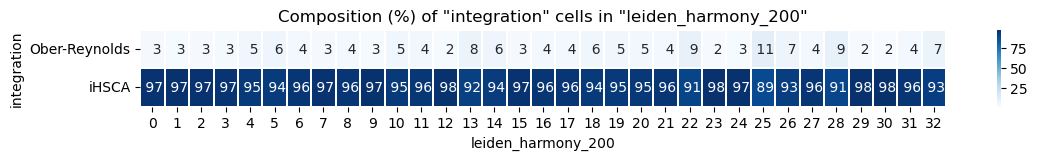

In [135]:
fig, ax = plt.subplots(figsize = (13, 1))
_ = plot_group_composition_heatmap(adata.obs, groupby_name = 'leiden_harmony_200', count_group_name = 'integration', ax = ax, cmap = 'Blues', transpose = True, lw = 0.02)

[fig.savefig(os.path.join(fig_path, f'KC_integration_iHSCA_OberReynolds_Confusion_leiden_200_horizontal.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Save

In [84]:
out_path = '/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset'
adata.write_h5ad(os.path.join(out_path, 'KC_integrated_with_OberReynolds_20260414.h5ad'))

In [3]:
out_path = '/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset'
adata = sc.read_h5ad(os.path.join(out_path, 'KC_integrated_with_OberReynolds_20260414.h5ad'), backed = 'r')

In [4]:
adata

AnnData object with n_obs × n_vars = 262860 × 24285 backed at '/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/KC_integrated_with_OberReynolds_20260414.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicit

In [108]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Integration'
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

[None]

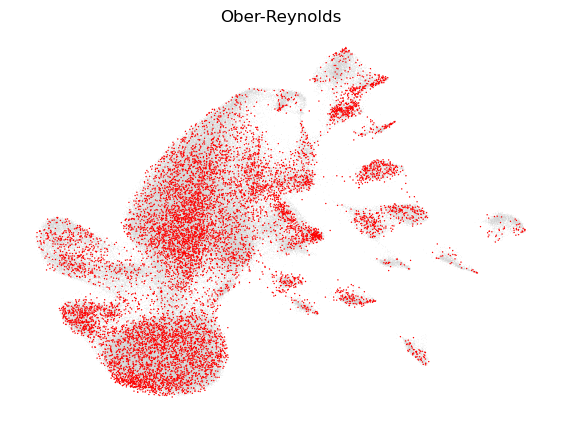

In [110]:
fig, ax = initialize_subplots(1, ncols = 1)
color = 'integration'
sc.pl.embedding(adata, basis = 'umap_harmony', frameon = False, show = False, ax = ax)
sc.pl.embedding(adata[adata.obs['integration']!='iHSCA'], basis = 'umap_harmony', color = color, frameon = False, show = False, ax = ax, palette = {'Ober-Reynolds': 'red'}, s = 4, title = 'Ober-Reynolds', legend_loc = None)

[fig.savefig(os.path.join(fig_path, f'KC_integration_iHSCA_OberReynolds_UMAP_mapping.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png']]

## Fig S6e

[None]

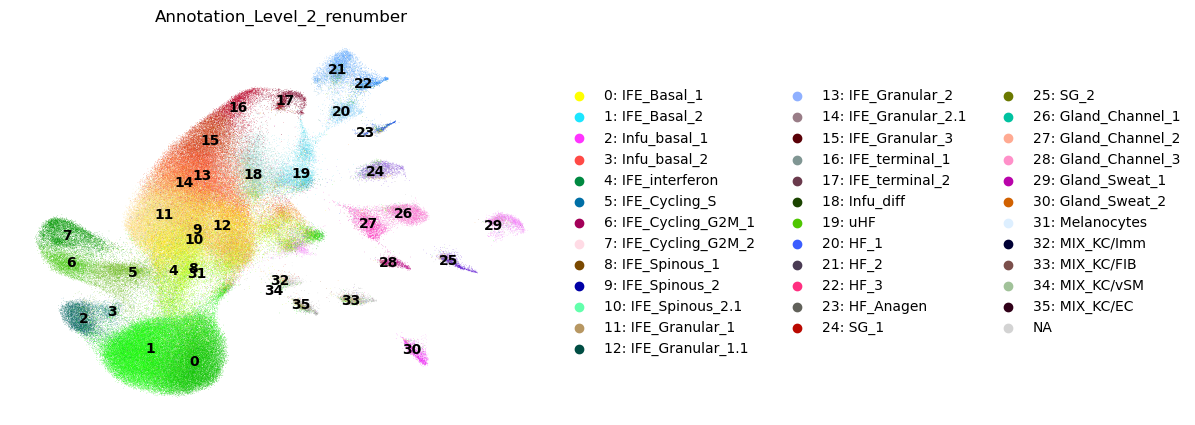

In [111]:
fig, ax = initialize_subplots(1, ncols = 1)

sc.pl.embedding(adata, basis = 'umap_harmony', color = 'Annotation_Level_2_FULL', frameon = False, show = False, ax = ax, s = 0)
sc.pl.embedding(adata[adata.obs['integration']=='iHSCA'], basis = 'umap_harmony', color = 'Annotation_Level_2_renumber', frameon = False, show = False, ax = ax, legend_loc = 'on data', palette = kc_colors)

[fig.savefig(os.path.join(fig_path, f'KC_integration_iHSCA_OberReynolds_UMAP_iHSCA_clusters.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png']]

## Fig S6f

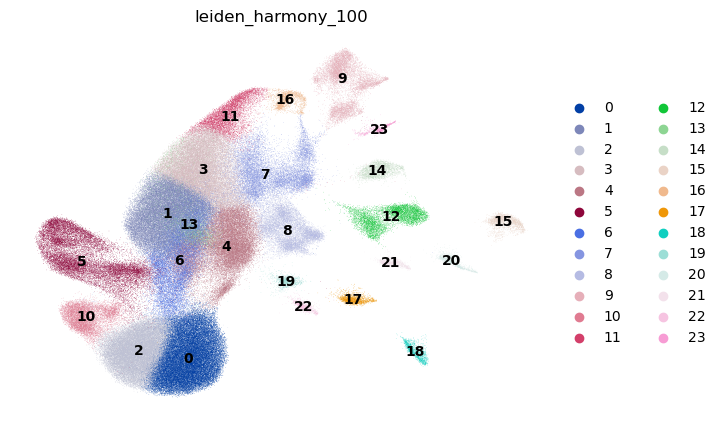

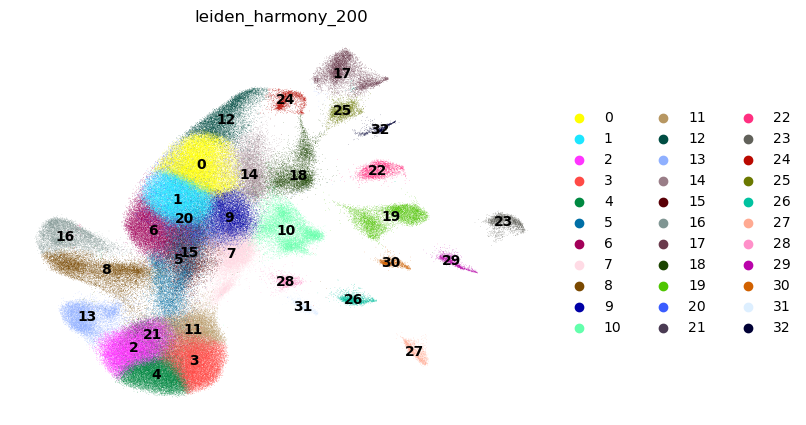

In [112]:
colors = ['leiden_harmony_100', 'leiden_harmony_200']
for ix, color in enumerate(colors):
    fig, ax = initialize_subplots(1, ncols = 1)
    
    sc.pl.embedding(adata, basis = 'umap_harmony', color = color, frameon = False, show = False, ax = ax)
    sc.pl.embedding(adata, basis = 'umap_harmony', color = color, frameon = False, show = False, ax = ax, legend_loc = 'on data', s = 0)

    [fig.savefig(os.path.join(fig_path, f'KC_integration_iHSCA_OberReynolds_UMAP_iHSCA_{color}.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png']]

In [103]:
adata.obs['total_normalized'] = np.array(adata.layers['normalized'].sum(axis = 1)).flatten()

In [137]:
adata.obsm['X_umap_harmony'] = adata.obsm['umap_harmony'].copy()
sc.tl.embedding_density(adata, basis = 'umap_harmony', groupby = 'integration')

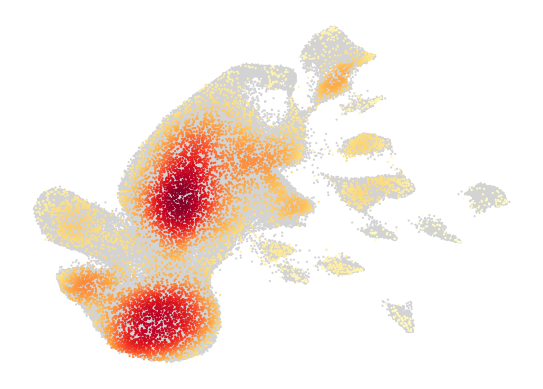

[None]

In [152]:
#fig, ax = plt.subplots(figsize = (7, 5))
fig = sc.pl.embedding_density(adata, basis = 'umap_harmony', key = 'umap_harmony_density_integration', group = 'Ober-Reynolds', s = 10, frameon = False, title = '', show = False, return_fig = True)
fig.get_axes()[1].remove()
plt.show(fig)

[fig.savefig(os.path.join(fig_path, f'KC_integration_iHSCA_OberReynolds_UMAP_OberReynolds_density.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png']]

## QC

In [5]:
sc.pp.calculate_qc_metrics(adata, layer = 'raw_counts', inplace = True)

In [6]:
df = adata.obs.copy()

In [7]:
df["log1p_counts_mean"] = (
    df["log1p_total_counts"]
    - df.groupby("DonorID")["log1p_total_counts"].transform("mean")
)
df["log1p_counts_median"] = (
    df["log1p_total_counts"]
    - df.groupby("DonorID")["log1p_total_counts"].transform("median")
)
df["log1p_counts_z"] = (
    df["log1p_total_counts"]
    - df.groupby("StudyID")["log1p_total_counts"].transform("mean")
) / df.groupby("StudyID")["log1p_total_counts"].transform("std")



In [8]:
df['source'] = np.where(df['study_id']=='Reynolds_Greenleaf_NatureGenetics_2023', 'OR', 'HSCA')

In [50]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping with Ober-Reynolds/Figures'

### Fig S6g

[None]

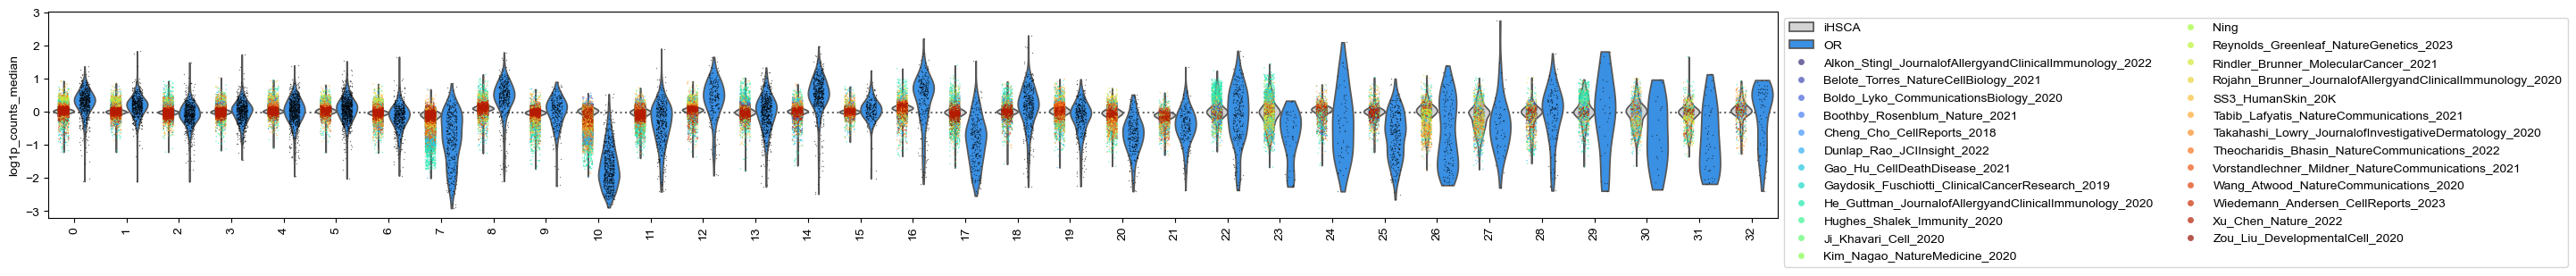

In [52]:
fig, ax = plt.subplots(figsize=(25, 3))
s = 1

#df = adata.obs.copy()
df['study'] = np.where(df['study_id']=='Reynolds_Greenleaf_NatureGenetics_2023', 'OR', 'iHSCA')

y = 'log1p_counts_median'
col = 'leiden_harmony_200'
#df['x'] = df[col].str.split(' - ').str[1].str.split(':').str[0].astype(int)
df['x'] = df[col]
order = natsorted(df['x'].unique())

# violins (categorical positions determined by order)
sbn.violinplot(
    data=df, x='x', y=y,
    order=order,
    density_norm='width', cut=0,
    hue='study', hue_order=['iHSCA', 'OR'],
    inner=None, palette={'iHSCA': 'lightgray', 'OR': 'dodgerblue'},
    ax=ax
)
pad = 0.2

# --- strip left (iHSCA): plot, then shift offsets ---
n_before = len(ax.collections)
sbn.stripplot(
    data=df.loc[df['study'] == 'iHSCA'],
    x='x', y=y,
    order=order,
    dodge=False, jitter=0.1, s=s,
    hue='StudyID', edgecolor=None, linewidth=0,
    ax=ax, alpha = 0.7, palette = 'turbo'
)
for coll in ax.collections[n_before:]:
    off = coll.get_offsets()
    off[:, 0] -= pad
    coll.set_offsets(off)
    coll.set_rasterized(True)

# --- strip right (Steele): plot, then shift offsets ---
n_before = len(ax.collections)
sbn.stripplot(
    data=df.loc[df['study'] == 'OR'],
    x='x', y=y,
    order=order,
    dodge=False, jitter=0.1, s=s,
    color='k', edgecolor=None, linewidth=0,
    ax=ax, alpha = 0.5
)
for coll in ax.collections[n_before:]:
    off = coll.get_offsets()
    off[:, 0] += pad
    coll.set_offsets(off)
    coll.set_rasterized(True)

ax.set_xticklabels(natsorted(df[col].unique()), rotation=90)
ax.set_xlabel('')

ax.axhline(df[y].mean(), ls = ':', zorder = -10, color = 'dimgray')

handles, labels = ax.get_legend_handles_labels()
ix = labels.index('OR')
#handles[ix].set_color('k')
#handles[ix].set_markerfacecolor('k')
#handles[ix].set_markeredgecolor('k')
#labels[-1] = labels.pop(ix)
#handles[-1] = handles.pop(ix)
ax.legend(handles = handles, labels = labels, bbox_to_anchor = (1,1), ncols = 2, markerscale = 5)

filename = 'Ober-Reynolds_mapping_QC_total_counts'
[fig.savefig(os.path.join(os.path.join(fig_path, f'{filename}.{f}')), bbox_inches = 'tight', dpi = 600) for f in ['pdf']]

# Save to Zenodo upload folder

In [28]:
adata.obs['SampleID'] = adata.obs['SampleID'].astype(object).fillna(adata.obs['sample_id'])

In [30]:
out_path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\UPLOAD_Zenodo')
adata.write_h5ad(os.path.join(out_path, 'Mapping_HSCA_Ober-Reynolds_L2_KC_new_integration.h5ad'))